<a href="https://colab.research.google.com/github/hyrinn/Machine_Learning/blob/main/Basecode_SupportVectorMachine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Machine (GD Method)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

## Dataset

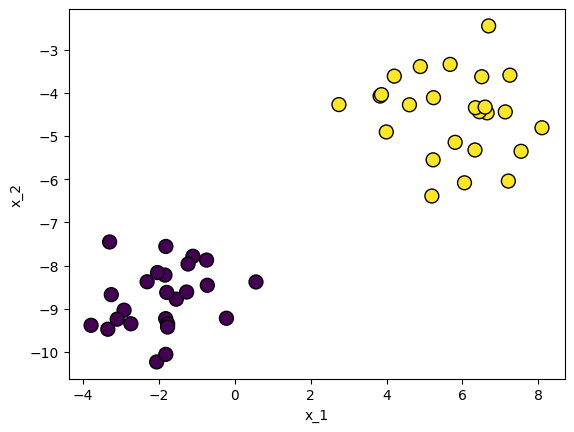

In [2]:
X, y = make_blobs(n_samples=50, n_features=2, centers=2, cluster_std=1.05, random_state=40)
plt.scatter(X[:, 0], X[:, 1], marker='o', c=y, s=100, edgecolor="k", linewidth=1)
plt.xlabel("x_1")
plt.ylabel("x_2")
plt.show()

## Model


In [3]:
class SVM:
    def __init__(self, learning_rate=0.001, n_iters=1000):
        # initialization
        self.lr = learning_rate
        self.n_iters = n_iters
        self.w = None
        self.b = None


    def fit(self, X, y):
        # Update parameters
        y_ = np.where(y <= 0, -1, 1) # 0 이하면 -1, 아니면 1의 값을 부여 => 데이터의 이진 분류를 위한 레이블을 생성
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for i in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) + self.b) >= 1 # 소수점일 경우에는 아래의 if문에 들어가서 w,b를 학습시킴

                if not condition:
                    self.w -= self.lr * (-np.dot(x_i, y_[idx]))
                    self.b -= self.lr * (y_[idx])

    def predict(self, X):
        # Prediction
        prediction = np.dot(X, self.w) + self.b
        prediction = np.sign(prediction) # 음수 : -1, 양수 : 1 로 매핑하는 함수
        return prediction


## Prediction

In [4]:
model = SVM()
model.fit(X, y)

print(model.w, model.b)

[0.63613331 0.15767898] -0.06500000000000004


In [5]:
margin = 2 / np.sqrt(np.dot(model.w.T, model.w))
print(margin)

3.051645856880161


## Visulization

In [6]:
def get_hyperplane_value(x, w, b, offset):
    return (-w[0] * x - b + offset) / w[1]

def visualize_svm(w, b):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    plt.scatter(X[:, 0], X[:, 1], marker="o", c=y)

    x0_1 = np.amin(X[:, 0])
    x0_2 = np.amax(X[:, 0])

    x1_1 = get_hyperplane_value(x0_1, w, b, 0)
    x1_2 = get_hyperplane_value(x0_2, w, b, 0)

    x1_1_m = get_hyperplane_value(x0_1, w, b, -1)
    x1_2_m = get_hyperplane_value(x0_2, w, b, -1)

    x1_1_p = get_hyperplane_value(x0_1, w, b, 1)
    x1_2_p = get_hyperplane_value(x0_2, w, b, 1)

    ax.plot([x0_1, x0_2], [x1_1, x1_2], "y--")
    ax.plot([x0_1, x0_2], [x1_1_m, x1_2_m], "k")
    ax.plot([x0_1, x0_2], [x1_1_p, x1_2_p], "k")

    x1_min = np.amin(X[:, 1])
    x1_max = np.amax(X[:, 1])
    ax.set_ylim([x1_min - 3, x1_max + 3])
    plt.xlabel("x_1")
    plt.ylabel("x_2")
    plt.show()

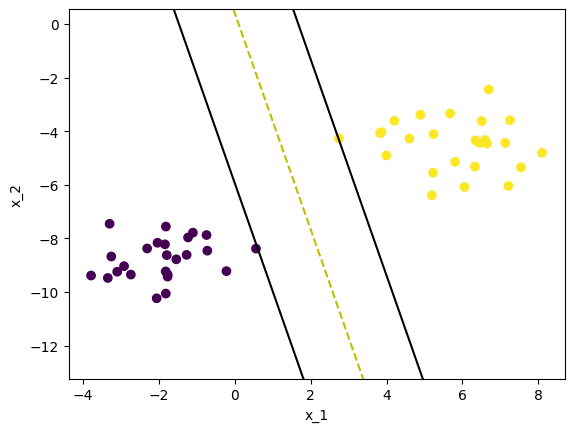

In [7]:
visualize_svm(model.w, model.b)

## scikit-learn 라이브러리를 이용한 SVM

In [8]:
from sklearn.svm import SVC
model = SVC(kernel='linear')
model.fit(X, y)

SVC(kernel='linear')

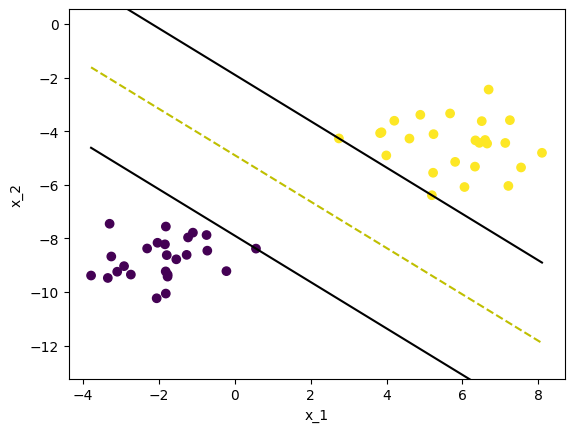

In [9]:
visualize_svm(model.coef_[0], model.intercept_)